# Evaluación — Recipe Recommendation System

**Inputs:** `df_final_embeddings.parquet`, `recipe_embeddings.npy`, `recipe_faiss.index`, `ingredient_coverage.csv`
**Outputs:** `evaluation_report.json`, `tsne_embeddings.png`, `limitations.csv`

In [1]:
# ==========================================
# 📦 INSTALLS
# ==========================================
!pip install sentence-transformers faiss-cpu pyarrow scikit-learn matplotlib tqdm -q
print("Installs OK")

Installs OK


In [2]:
# ==========================================
# 📦 IMPORTS
# ==========================================
import json
import ast
import os
import re
import datetime
import numpy as np
import pandas as pd
import faiss
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
from IPython.display import display

# Use non-interactive backend when running headless
matplotlib.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"

print("Imports OK")

Imports OK


In [3]:
# ==========================================
# 📂 CARGAR ARCHIVOS
# ==========================================
print("Cargando datos...")

# DataFrame con embedding_text e imágenes
df = pd.read_parquet("df_final_embeddings.parquet")
print(f"  df_final_embeddings : {df.shape}")

# Embeddings numpy (n × 384, float32, L2-normalizado)
embeddings = np.load("recipe_embeddings.npy").astype(np.float32)
print(f"  recipe_embeddings   : {embeddings.shape}  dtype={embeddings.dtype}")

# Índice FAISS
index = faiss.read_index("recipe_faiss.index")
print(f"  recipe_faiss.index  : {index.ntotal:,} vectores  dim={index.d}")

# Cobertura de imágenes de ingredientes
df_cov = pd.read_csv("ingredient_coverage.csv")
print(f"  ingredient_coverage : {df_cov.shape}  cols={df_cov.columns.tolist()}")

assert len(df) == index.ntotal == len(embeddings), (
    f"Inconsistencia de tamaños: df={len(df)} index={index.ntotal} emb={len(embeddings)}"
)
print(f"\n✓ Todos los archivos cargados y alineados ({len(df):,} recetas).")

Cargando datos...
  df_final_embeddings : (60614, 46)
  recipe_embeddings   : (60614, 384)  dtype=float32
  recipe_faiss.index  : 60,614 vectores  dim=384
  ingredient_coverage : (46882, 4)  cols=['ingredient_name', 'frequency', 'has_image', 'match_score']

✓ Todos los archivos cargados y alineados (60,614 recetas).


In [4]:
# ==========================================
# DETECCIÓN DE COLUMNAS
# ==========================================
INGR_COL = next(
    (c for c in ["ingredients_text_processed", "ingredient_text"] if c in df.columns),
    None,
)
DIET_COL = next(
    (c for c in ["dietary_profile_updated", "dietary_profile"] if c in df.columns),
    None,
)
IMG_COL = next(
    (c for c in ["dish_image_path", "dish_image"] if c in df.columns),
    None,
)

print(f"INGR_COL : {INGR_COL}")
print(f"DIET_COL : {DIET_COL}")
print(f"IMG_COL  : {IMG_COL}")
assert INGR_COL and DIET_COL, "Columna de ingredientes o dietética no encontrada."


def parse_json_list(val):
    """Parsea una cadena JSON/Python list. Devuelve lista vacía si falla."""
    if pd.isna(val) or str(val).strip() in ("", "[]", "nan"):
        return []
    try:
        r = json.loads(val)
        return r if isinstance(r, list) else []
    except Exception:
        try:
            r = ast.literal_eval(str(val))
            return r if isinstance(r, list) else []
        except Exception:
            return []


print("\nMuestra cook_speed:", df["cook_speed"].value_counts().to_dict())

INGR_COL : ingredient_text
DIET_COL : dietary_profile
IMG_COL  : dish_image_path

Muestra cook_speed: {'fast': 46132, 'medium': 13279, 'slow': 1203}


## A. Cobertura del dataset

In [5]:
# ==========================================
# A1: MÉTRICAS NUMÉRICAS DE COBERTURA
# ==========================================
SEP = "=" * 60

total_recipes = len(df)

# Cobertura de imagen de platillo
if IMG_COL:
    n_with_dish = int(df[IMG_COL].notna().sum())
    pct_dish    = round(n_with_dish / total_recipes * 100, 2)
else:
    n_with_dish, pct_dish = 0, 0.0

# Cobertura de imágenes de ingredientes (ingredient_coverage.csv)
has_img_col = next(
    (c for c in ["has_image", "has_img", "with_image"] if c in df_cov.columns),
    None,
)
freq_col = next(
    (c for c in ["frequency", "freq", "count"] if c in df_cov.columns),
    None,
)

if has_img_col and freq_col:
    total_apps   = int(df_cov[freq_col].sum())
    covered_apps = int(df_cov.loc[df_cov[has_img_col] == True, freq_col].sum())
    pct_ingr_weighted  = round(covered_apps / total_apps * 100, 2)
    pct_ingr_unique    = round(df_cov[has_img_col].mean() * 100, 2)
else:
    pct_ingr_weighted, pct_ingr_unique = None, None

print(SEP)
print("A. COBERTURA DEL DATASET")
print(SEP)
print(f"  Total recetas                          : {total_recipes:>7,}")
print(f"  Con imagen de platillo (dish_image)    : {n_with_dish:>7,}  ({pct_dish:.1f}%)")
if pct_ingr_weighted:
    print(f"  Ingredientes con imagen (ponderado)    : {pct_ingr_weighted:.1f}%  "
          f"({covered_apps:,}/{total_apps:,} apariciones)")
    print(f"  Ingredientes únicos con imagen         : {pct_ingr_unique:.1f}%")

A. COBERTURA DEL DATASET
  Total recetas                          :  60,614
  Con imagen de platillo (dish_image)    :   3,292  (5.4%)
  Ingredientes con imagen (ponderado)    : 84.3%  (472,272/560,115 apariciones)
  Ingredientes únicos con imagen         : 81.4%


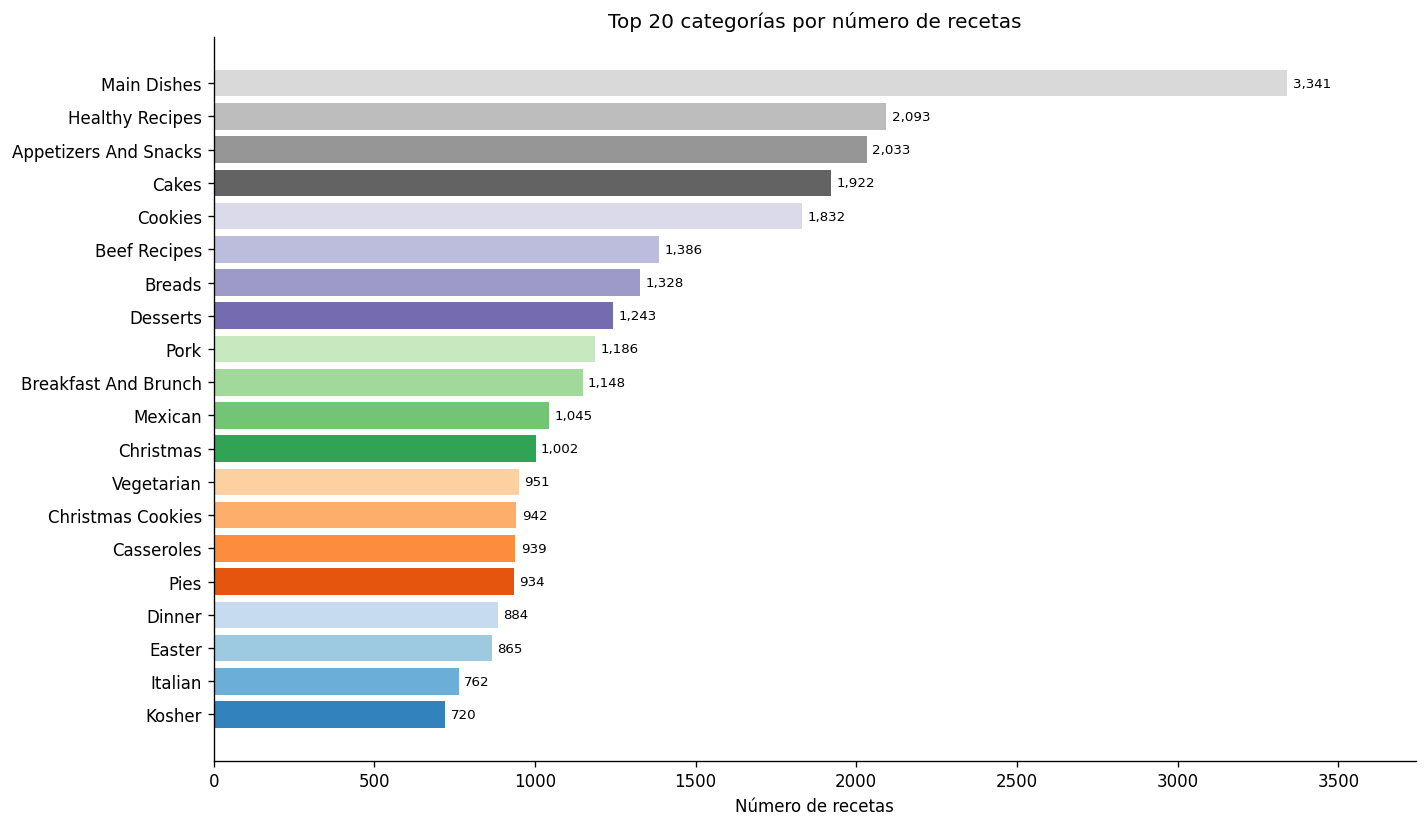

Saved: category_distribution.png


In [6]:
# ==========================================
# A2: DISTRIBUCIÓN POR CATEGORÍA (barplot)
# ==========================================
cat_counts = df["category"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    cat_counts.index[::-1],
    cat_counts.values[::-1],
    color=cm.tab20c(np.linspace(0, 1, len(cat_counts))),
)
# Etiqueta de valor a la derecha de cada barra
for bar, val in zip(bars, cat_counts.values[::-1]):
    ax.text(
        bar.get_width() + cat_counts.max() * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        fontsize=8,
    )
ax.set_xlabel("Número de recetas")
ax.set_title("Top 20 categorías por número de recetas")
ax.set_xlim(0, cat_counts.max() * 1.12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("category_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: category_distribution.png")

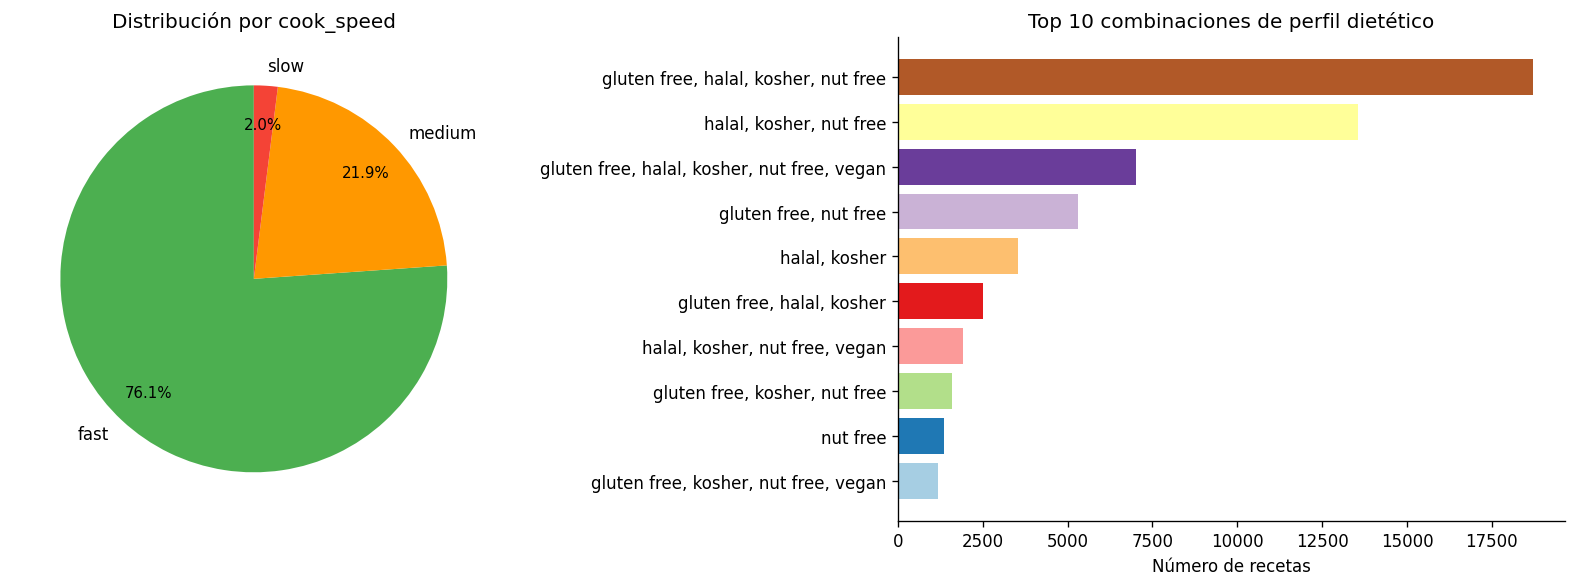

Saved: distributions.png

Top 10 combinaciones dietéticas:
  18,705  gluten free, halal, kosher, nut free
  13,549  halal, kosher, nut free
   7,029  gluten free, halal, kosher, nut free, vegan
   5,320  gluten free, nut free
   3,542  halal, kosher
   2,517  gluten free, halal, kosher
   1,919  halal, kosher, nut free, vegan
   1,585  gluten free, kosher, nut free
   1,364  nut free
   1,172  gluten free, kosher, nut free, vegan


In [7]:
# ==========================================
# A3: DISTRIBUCIONES DE cook_speed Y dietary_profile
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Cook speed ────────────────────────────────────────────────────────────────
speed_counts = df["cook_speed"].value_counts()
SPEED_COLORS = {"fast": "#4caf50", "medium": "#ff9800",
                "slow": "#f44336", "unspecified": "#9e9e9e"}
colors_speed = [SPEED_COLORS.get(k, "#607d8b") for k in speed_counts.index]
wedges, texts, autotexts = axes[0].pie(
    speed_counts.values,
    labels=speed_counts.index,
    colors=colors_speed,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.80,
)
for at in autotexts:
    at.set_fontsize(9)
axes[0].set_title("Distribución por cook_speed")

# ── Top 10 combinaciones de dietary_profile ───────────────────────────────────
def canonical_diet(val):
    items = parse_json_list(val)
    if not items:
        return "(sin perfil)"
    return ", ".join(sorted(str(x).replace("_", " ") for x in items))

diet_combos = df[DIET_COL].apply(canonical_diet).value_counts().head(10)
axes[1].barh(
    [t[:45] for t in diet_combos.index[::-1]],
    diet_combos.values[::-1],
    color=cm.Paired(np.linspace(0, 1, len(diet_combos))),
)
axes[1].set_xlabel("Número de recetas")
axes[1].set_title("Top 10 combinaciones de perfil dietético")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: distributions.png")

# Tabla de top 10 combinaciones
print("\nTop 10 combinaciones dietéticas:")
for combo, cnt in diet_combos.items():
    print(f"  {cnt:>6,}  {combo}")

# Guardar para el JSON
speed_dist = df["cook_speed"].value_counts().to_dict()
diet_top10 = [
    {"combination": k, "count": int(v)} for k, v in diet_combos.items()
]
top15_cats = [
    {"category": k, "count": int(v)}
    for k, v in df["category"].value_counts().head(15).items()
]

---
## B. Retrieval Quality

20 queries con `expected_keywords`. Relevante = ≥1 keyword en `recipe_title + embedding_text`. Métricas: P@5 y MRR@10.

In [8]:
# ==========================================
# B1: CARGAR MODELO Y DEFINIR TEST SET
# ==========================================
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
print(f"Cargando modelo: {MODEL_NAME}")
model = SentenceTransformer(MODEL_NAME)
print("Modelo cargado.\n")

TEST_QUERIES = [
    # ── EN: Vegetarian / Vegan ──────────────────────────────────────────────────
    {"id":  1, "query": "quick vegetarian pasta dinner",
     "expected_keywords": ["pasta", "vegetarian"]},
    {"id":  2, "query": "easy vegan stir fry with tofu",
     "expected_keywords": ["tofu", "vegan"]},
    # ── EN: Meat / Slow cook ────────────────────────────────────────────────────
    {"id":  3, "query": "slow cooked beef stew hearty",
     "expected_keywords": ["beef", "stew"]},
    {"id":  4, "query": "braised lamb with herbs and red wine",
     "expected_keywords": ["lamb"]},
    # ── EN: Dietary restrictions ────────────────────────────────────────────────
    {"id":  5, "query": "gluten free chocolate dessert cake",
     "expected_keywords": ["chocolate", "gluten"]},
    {"id":  6, "query": "dairy free coconut milk curry",
     "expected_keywords": ["coconut", "curry"]},
    {"id":  7, "query": "nut free kids lunch sandwich wrap",
     "expected_keywords": ["sandwich", "wrap"]},
    # ── EN: Cuisine types ───────────────────────────────────────────────────────
    {"id":  8, "query": "italian homemade pizza margherita",
     "expected_keywords": ["pizza"]},
    {"id":  9, "query": "thai green curry spicy vegetables",
     "expected_keywords": ["curry", "thai"]},
    {"id": 10, "query": "mexican guacamole avocado fresh lime",
     "expected_keywords": ["avocado", "guacamole"]},
    # ── EN: Meal types / courses ────────────────────────────────────────────────
    {"id": 11, "query": "quick scrambled eggs breakfast",
     "expected_keywords": ["egg", "breakfast"]},
    {"id": 12, "query": "chocolate chip cookies homemade baking",
     "expected_keywords": ["chocolate", "cookie"]},
    {"id": 13, "query": "fresh green salad with avocado lemon dressing",
     "expected_keywords": ["salad", "avocado"]},
    # ── EN: Seafood ─────────────────────────────────────────────────────────────
    {"id": 14, "query": "shrimp pasta garlic butter lemon",
     "expected_keywords": ["shrimp", "pasta"]},
    {"id": 15, "query": "baked salmon with vegetables healthy",
     "expected_keywords": ["salmon"]},
    # ── EN: Soups ───────────────────────────────────────────────────────────────
    {"id": 16, "query": "lentil soup vegan hearty winter",
     "expected_keywords": ["lentil", "soup"]},
    {"id": 17, "query": "tomato basil soup vegetarian creamy",
     "expected_keywords": ["tomato", "soup"]},
    # ── Cross-lingual: ES ───────────────────────────────────────────────────────
    {"id": 18, "query": "pollo asado con limón y ajo rápido",
     "expected_keywords": ["chicken", "lemon"]},
    {"id": 19, "query": "ensalada fresca vegetariana con aguacate",
     "expected_keywords": ["salad", "avocado"]},
    # ── Cross-lingual: FR ───────────────────────────────────────────────────────
    {"id": 20, "query": "gâteau au chocolat facile rapide sans gluten",
     "expected_keywords": ["chocolate", "gluten"]},
]

print(f"Test set definido: {len(TEST_QUERIES)} queries")
print(f"  EN monolingüe: {sum(1 for q in TEST_QUERIES if q['id'] <= 17)}")
print(f"  Cross-lingual : {sum(1 for q in TEST_QUERIES if q['id'] >= 18)}")

Cargando modelo: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Modelo cargado.

Test set definido: 20 queries
  EN monolingüe: 17
  Cross-lingual : 3


In [9]:
# ==========================================
# B2: EJECUTAR EVALUACIÓN (P@5 y MRR)
# ==========================================
K_EVAL = 10  # recuperar top-10 para calcular MRR; P@5 usa solo los primeros 5


def is_relevant(row, keywords):
    """True si algún keyword aparece en recipe_title o embedding_text."""
    combined = " ".join([
        str(row.get("recipe_title", "")),
        str(row.get("embedding_text", "")),
    ]).lower()
    return any(kw.lower() in combined for kw in keywords)


results_per_query = []

for q in tqdm(TEST_QUERIES, desc="Evaluando queries"):
    q_emb = model.encode(
        [q["query"]], normalize_embeddings=True, convert_to_numpy=True
    ).astype(np.float32)

    scores, indices = index.search(q_emb, K_EVAL)
    top_rows = [df.iloc[idx] for idx in indices[0]]

    # Relevance vector (1=relevant, 0=not)
    rel = [1 if is_relevant(r, q["expected_keywords"]) else 0 for r in top_rows]

    # Precision@5
    p5 = sum(rel[:5]) / 5.0

    # Reciprocal Rank (first relevant in top-10, 1-indexed)
    rr = 0.0
    for rank, r in enumerate(rel, 1):
        if r == 1:
            rr = 1.0 / rank
            break

    results_per_query.append({
        "id":              q["id"],
        "query":           q["query"],
        "expected":        ", ".join(q["expected_keywords"]),
        "precision_at_5":  round(p5, 3),
        "reciprocal_rank": round(rr, 3),
        "relevance_top10": rel,
        "top1_title":      top_rows[0]["recipe_title"] if top_rows else "",
        "top1_score":      round(float(scores[0][0]), 4),
    })

mean_p5  = round(np.mean([r["precision_at_5"]  for r in results_per_query]), 4)
mean_mrr = round(np.mean([r["reciprocal_rank"] for r in results_per_query]), 4)

print(f"\nEvaluación completada:")
print(f"  Mean Precision@5 : {mean_p5:.4f}")
print(f"  Mean MRR         : {mean_mrr:.4f}")

Evaluando queries:   0%|          | 0/20 [00:00<?, ?it/s]


Evaluación completada:
  Mean Precision@5 : 0.9300
  Mean MRR         : 0.9666


In [10]:
# ==========================================
# B3: TABLA DE RESULTADOS POR QUERY
# ==========================================
df_results = pd.DataFrame([
    {
        "id":    r["id"],
        "query": r["query"][:45] + "..." if len(r["query"]) > 45 else r["query"],
        "expected_keywords": r["expected"],
        "P@5":  r["precision_at_5"],
        "RR":   r["reciprocal_rank"],
        "top1_title": r["top1_title"][:50],
        "top1_sim":   r["top1_score"],
    }
    for r in results_per_query
])

pd.set_option("display.max_colwidth", 55)
pd.set_option("display.width", 140)
display(df_results.set_index("id"))

print("\n" + "=" * 60)
print(f"  GLOBAL  Mean P@5 = {mean_p5:.4f}   Mean MRR = {mean_mrr:.4f}")
print("=" * 60)

# Métricas por tipo de query
en_ids  = [r for r in results_per_query if r["id"] <= 17]
xl_ids  = [r for r in results_per_query if r["id"] >= 18]
print(f"  EN monolingüe (n={len(en_ids):2d})  P@5={np.mean([r['precision_at_5']  for r in en_ids]):.4f}  "
      f"MRR={np.mean([r['reciprocal_rank'] for r in en_ids]):.4f}")
print(f"  Cross-lingual  (n={len(xl_ids):2d})  P@5={np.mean([r['precision_at_5']  for r in xl_ids]):.4f}  "
      f"MRR={np.mean([r['reciprocal_rank'] for r in xl_ids]):.4f}")

,query,expected_keywords,P@5,RR,top1_title,top1_sim
id,,,,,,
1,quick vegetarian pasta dinner,"pasta, vegetarian",1.0,1.000,Quick Pasta Sauce,0.7505
2,easy vegan stir fry with tofu,"tofu, vegan",1.0,1.000,Air Fryer Tofu,0.7682
3,slow cooked beef stew hearty,"beef, stew",1.0,1.000,Hearty Slow Cooker Beef Stew,0.7821
4,braised lamb with herbs and red wine,lamb,1.0,1.000,Red Wine-Braised Lamb Shanks,0.7201
5,gluten free chocolate dessert cake,"chocolate, gluten",1.0,1.000,Flourless Chocolate Cake,0.7641
6,dairy free coconut milk curry,"coconut, curry",1.0,1.000,Vegetable Curry with Coconut Milk,0.6954
7,nut free kids lunch sandwich wrap,"sandwich, wrap",0.8,1.000,School Lunch Bagel Sandwich,0.6170
8,italian homemade pizza margherita,pizza,1.0,1.000,Four Cheese Margherita Pizza,0.7834
9,thai green curry spicy vegetables,"curry, thai",1.0,1.000,Authentic Thai Green Curry,0.7847



  GLOBAL  Mean P@5 = 0.9300   Mean MRR = 0.9666
  EN monolingüe (n=17)  P@5=0.9882  MRR=1.0000
  Cross-lingual  (n= 3)  P@5=0.6000  MRR=0.7777


---
## C. Diversidad del espacio latente

Distancia coseno = `1 − (a · b)`. Se espera `dist_same_cat < dist_diff_cat`.

In [11]:
# ==========================================
# C1: DISTANCIAS COSENO
# ==========================================
np.random.seed(42)
N_PAIRS = 1_000

# ── 1. Pares aleatorios ──────────────────────────────────────────────────────
idx_a = np.random.choice(len(embeddings), N_PAIRS, replace=False)
idx_b = np.random.choice(len(embeddings), N_PAIRS, replace=False)
# Evitar pares idénticos
same_mask = idx_a == idx_b
idx_b[same_mask] = (idx_b[same_mask] + 1) % len(embeddings)

# Inner product de vectores normalizados = cosine similarity
cos_sim_random = np.sum(embeddings[idx_a] * embeddings[idx_b], axis=1)
dist_random    = 1.0 - cos_sim_random
mean_dist_random = float(dist_random.mean())

# ── 2. Pares misma categoría y diferente categoría ───────────────────────────
# Muestra de 3000 recetas con su categoría para formar pares controlados
sample_n   = min(3000, len(df))
sample_idx = np.random.choice(len(df), sample_n, replace=False)
emb_samp   = embeddings[sample_idx]
cats_samp  = df["category"].iloc[sample_idx].values

dists_same, dists_diff = [], []
target_per_class = max(50, N_PAIRS // 2)

while len(dists_same) < target_per_class or len(dists_diff) < target_per_class:
    i, j = np.random.randint(0, sample_n, 2)
    if i == j:
        continue
    d = 1.0 - float(np.dot(emb_samp[i], emb_samp[j]))
    if cats_samp[i] == cats_samp[j] and len(dists_same) < target_per_class:
        dists_same.append(d)
    elif cats_samp[i] != cats_samp[j] and len(dists_diff) < target_per_class:
        dists_diff.append(d)

mean_dist_same = float(np.mean(dists_same))
mean_dist_diff = float(np.mean(dists_diff))
diversity_ratio = round(mean_dist_diff / mean_dist_same, 4) if mean_dist_same > 0 else None

SEP = "=" * 60
print(SEP)
print("C. ANÁLISIS DE DIVERSIDAD DEL ESPACIO LATENTE")
print(SEP)
print(f"  Dist. coseno media — pares aleatorios   : {mean_dist_random:.4f}")
print(f"  Dist. coseno media — misma categoría    : {mean_dist_same:.4f}")
print(f"  Dist. coseno media — diferente categoría: {mean_dist_diff:.4f}")
print(f"  Ratio distancia (diff/same)             : {diversity_ratio:.4f}")
print()

if mean_dist_same < mean_dist_diff:
    print("  ✓ dist_same < dist_diff — el espacio captura agrupación semántica por categoría")
else:
    print("  ✗ dist_same >= dist_diff — las categorías no forman clusters claros (puede ser esperable")
    print("    si las categorías son muy generales o si los títulos/ingredientes no las diferencian bien)")

C. ANÁLISIS DE DIVERSIDAD DEL ESPACIO LATENTE
  Dist. coseno media — pares aleatorios   : 0.5950
  Dist. coseno media — misma categoría    : 0.4782
  Dist. coseno media — diferente categoría: 0.6092
  Ratio distancia (diff/same)             : 1.2740

  ✓ dist_same < dist_diff — el espacio captura agrupación semántica por categoría


PCA 384 → 50 dimensiones sobre 2000 recetas...
Varianza explicada por PCA: 71.28%
t-SNE 50 → 2 dimensiones (perplexity=30)...
t-SNE completado. KL divergence: 1.3105


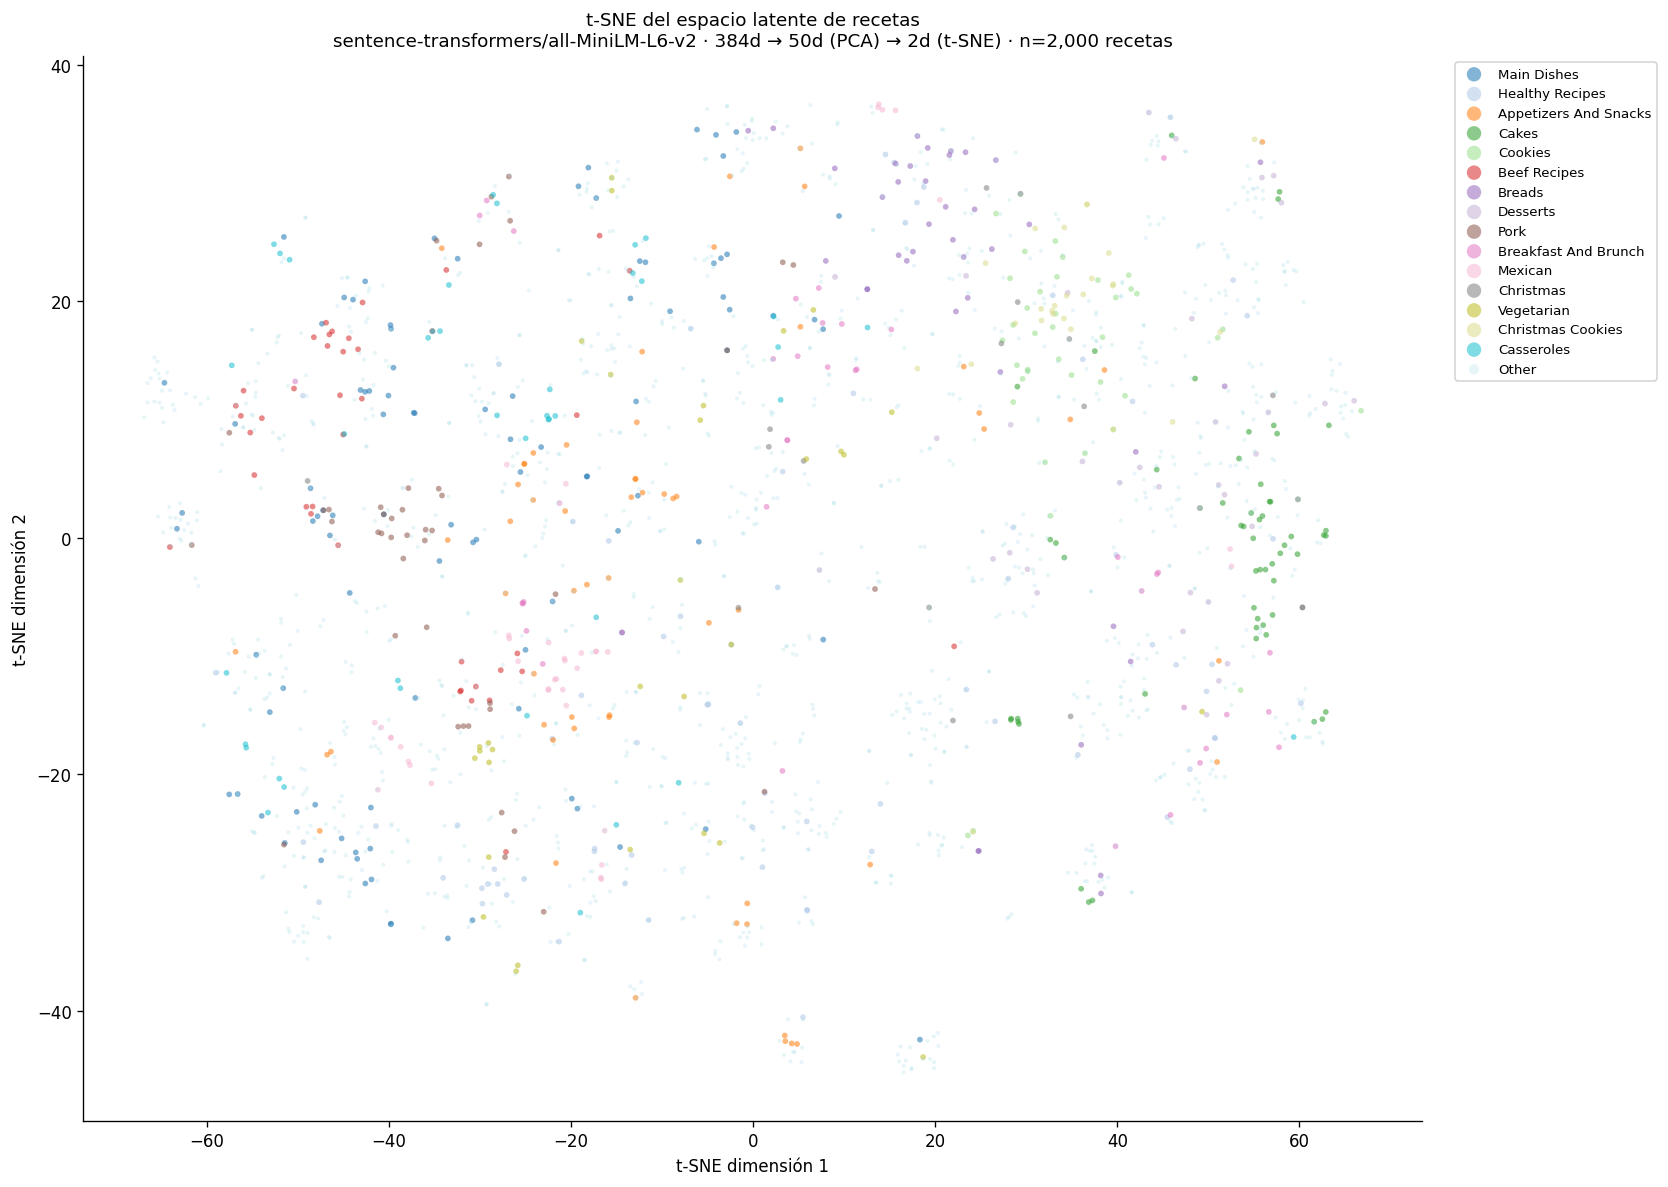

Saved: tsne_embeddings.png


In [12]:
# ==========================================
# C2: t-SNE + VISUALIZACIÓN
# ==========================================
N_TSNE = min(2000, len(df))
N_TOP_CATS = 15  # categorías con color propio; resto → "Other"

tsne_idx = np.random.choice(len(df), N_TSNE, replace=False)
emb_tsne = embeddings[tsne_idx]
df_tsne  = df.iloc[tsne_idx].reset_index(drop=True)

# Reducir con PCA a 50d antes de t-SNE (acelera y estabiliza)
from sklearn.decomposition import PCA
print(f"PCA 384 → 50 dimensiones sobre {N_TSNE} recetas...")
pca = PCA(n_components=50, random_state=42)
emb_pca = pca.fit_transform(emb_tsne)
print(f"Varianza explicada por PCA: {pca.explained_variance_ratio_.sum():.2%}")

print(f"t-SNE 50 → 2 dimensiones (perplexity=30)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42,
            max_iter=1000, learning_rate="auto", init="pca")
emb_2d = tsne.fit_transform(emb_pca)
print(f"t-SNE completado. KL divergence: {tsne.kl_divergence_:.4f}")

# Asignar etiqueta de categoría (top N_TOP_CATS + Other)
top_cats = df["category"].value_counts().head(N_TOP_CATS).index.tolist()
df_tsne["cat_label"] = df_tsne["category"].apply(
    lambda c: c if c in top_cats else "Other"
)
cats_ordered = top_cats + (["Other"] if "Other" in df_tsne["cat_label"].values else [])

# Paleta de colores (compatible matplotlib ≥3.7)
try:
    cmap = matplotlib.colormaps.get_cmap("tab20")
except AttributeError:
    cmap = cm.get_cmap("tab20")
colors = {cat: cmap(i / max(len(cats_ordered) - 1, 1)) for i, cat in enumerate(cats_ordered)}

fig, ax = plt.subplots(figsize=(14, 10))
for cat in cats_ordered:
    mask = df_tsne["cat_label"] == cat
    ax.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        c=[colors[cat]], label=cat,
        alpha=0.55 if cat != "Other" else 0.25,
        s=12 if cat != "Other" else 6,
        edgecolors="none",
    )

ax.legend(
    markerscale=2.5,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    framealpha=0.8,
)
ax.set_title(
    f"t-SNE del espacio latente de recetas\n"
    f"sentence-transformers/all-MiniLM-L6-v2 · 384d → 50d (PCA) → 2d (t-SNE) · "
    f"n={N_TSNE:,} recetas",
    fontsize=11,
)
ax.set_xlabel("t-SNE dimensión 1")
ax.set_ylabel("t-SNE dimensión 2")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("tsne_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: tsne_embeddings.png")

---
## D. Limitaciones y mejoras

In [13]:
# ==========================================
# D: TABLA DE LIMITACIONES
# ==========================================
limitations_data = [
    {
        "limitacion": "Cobertura parcial de imágenes de ingredientes (~81% único, ~84% ponderado)",
        "impacto": "medio",
        "mejora_propuesta": (
            "Integrar Open Food Facts API o scraping de Wikimedia Commons "
            "para ingredientes sin cobertura; priorizar los 8,712 ingredientes únicos sin imagen"
        ),
        "esfuerzo_estimado": "alto",
    },
    {
        "limitacion": "Truncamiento de recetas largas a 512 tokens (pérdida de pasos finales)",
        "impacto": "medio",
        "mejora_propuesta": (
            "Usar modelos con ventana extendida (all-mpnet-base-v2 o Longformer) "
            "o chunking jerárquico: embed por sección y agregar con weighted pooling"
        ),
        "esfuerzo_estimado": "medio",
    },
    {
        "limitacion": "Sistema retrieval-based sin generación real (dependencia de LLM downstream)",
        "impacto": "alto",
        "mejora_propuesta": (
            "Integrar LLM downstream (GPT-2 fine-tuned o GPT-4 via API) para reformulación "
            "y personalización; el retrieval provee contexto, el LLM genera texto adaptado"
        ),
        "esfuerzo_estimado": "alto",
    },
    {
        "limitacion": "Sesgo hacia cocina occidental (Fruits-360 + Epicurious como fuentes principales)",
        "impacto": "medio",
        "mejora_propuesta": (
            "Añadir datasets de cocina asiática, latinoamericana y africana "
            "(Yummly, AllRecipes API, Tasty API); rebalancear ingredient_catalog con fuentes locales"
        ),
        "esfuerzo_estimado": "alto",
    },
    {
        "limitacion": "Sin validación humana de los matches fuzzy de ingredientes (threshold 72)",
        "impacto": "bajo",
        "mejora_propuesta": (
            "Crear interfaz de validación manual (Streamlit) o crowdsourcing para verificar "
            "matches con score < 85; marcar los inciertos con flag 'fuzzy_unverified'"
        ),
        "esfuerzo_estimado": "medio",
    },
    {
        "limitacion": "Ausencia de feedback loop — sin fine-tuning sobre preferencias reales",
        "impacto": "alto",
        "mejora_propuesta": (
            "Implementar bi-encoder fine-tuning con pares (query, receta_preferida) "
            "usando MNRL loss; recolectar señales implícitas (clicks, tiempo en página)"
        ),
        "esfuerzo_estimado": "alto",
    },
    {
        "limitacion": "Cobertura de imagen de platillo muy baja (~5.4% via Epicurious)",
        "impacto": "medio",
        "mejora_propuesta": (
            "Buscar datasets adicionales de imágenes de platos (Food-101, UEC-Food256) "
            "y aplicar matching por categoría; o usar DALL-E/Stable Diffusion para generar imágenes"
        ),
        "esfuerzo_estimado": "medio",
    },
]

df_lim = pd.DataFrame(limitations_data)

pd.set_option("display.max_colwidth", 80)
display(df_lim)

df_lim.to_csv("limitations.csv", index=False, encoding="utf-8")
print(f"\nSaved: limitations.csv  ({len(df_lim)} filas)")

# Resumen por impacto
print("\nLimitaciones por nivel de impacto:")
for level in ["alto", "medio", "bajo"]:
    n = (df_lim["impacto"] == level).sum()
    print(f"  {level:<6}: {n}")

,limitacion,impacto,mejora_propuesta,esfuerzo_estimado
0,"Cobertura parcial de imágenes de ingredientes (~81% único, ~84% ponderado)",medio,Integrar Open Food Facts API o scraping de Wikimedia Commons para ingredient...,alto
1,Truncamiento de recetas largas a 512 tokens (pérdida de pasos finales),medio,Usar modelos con ventana extendida (all-mpnet-base-v2 o Longformer) o chunki...,medio
2,Sistema retrieval-based sin generación real (dependencia de LLM downstream),alto,Integrar LLM downstream (GPT-2 fine-tuned o GPT-4 via API) para reformulació...,alto
3,Sesgo hacia cocina occidental (Fruits-360 + Epicurious como fuentes principa...,medio,"Añadir datasets de cocina asiática, latinoamericana y africana (Yummly, AllR...",alto
4,Sin validación humana de los matches fuzzy de ingredientes (threshold 72),bajo,Crear interfaz de validación manual (Streamlit) o crowdsourcing para verific...,medio
5,Ausencia de feedback loop — sin fine-tuning sobre preferencias reales,alto,"Implementar bi-encoder fine-tuning con pares (query, receta_preferida) usand...",alto
6,Cobertura de imagen de platillo muy baja (~5.4% via Epicurious),medio,"Buscar datasets adicionales de imágenes de platos (Food-101, UEC-Food256) y ...",medio



Saved: limitations.csv  (7 filas)

Limitaciones por nivel de impacto:
  alto  : 2
  medio : 4
  bajo  : 1


---
## Guardar `evaluation_report.json`

In [14]:
# ==========================================
# GENERAR evaluation_report.json
# ==========================================
report = {
    "generated_at":  datetime.datetime.utcnow().isoformat() + "Z",
    "model":         MODEL_NAME,
    "embedding_dim": int(embeddings.shape[1]),
    "dataset":       "wafaaelhusseini/extended-recipes-dataset-64k-dishes",

    "A_dataset_coverage": {
        "total_recipes":                  total_recipes,
        "n_with_dish_image":              n_with_dish,
        "pct_with_dish_image":            pct_dish,
        "pct_ingredients_with_image_weighted": pct_ingr_weighted,
        "pct_ingredients_unique_with_image":   pct_ingr_unique,
        "cook_speed_distribution":        {k: int(v) for k, v in speed_dist.items()},
        "top_15_categories":              top15_cats,
        "top_10_dietary_combinations":    diet_top10,
    },

    "B_retrieval_quality": {
        "n_queries":            len(TEST_QUERIES),
        "k_retrieved":          K_EVAL,
        "mean_precision_at_5":  mean_p5,
        "mean_mrr":             mean_mrr,
        "note": (
            "Relevancia definida como: al menos 1 expected_keyword presente en "
            "recipe_title + embedding_text (case-insensitive substring match)"
        ),
        "per_query": [
            {
                "id":              r["id"],
                "query":           r["query"],
                "expected":        r["expected"],
                "precision_at_5":  r["precision_at_5"],
                "reciprocal_rank": r["reciprocal_rank"],
                "top1_title":      r["top1_title"],
                "top1_similarity": r["top1_score"],
            }
            for r in results_per_query
        ],
    },

    "C_embedding_diversity": {
        "n_random_pairs":               N_PAIRS,
        "n_category_pairs_each":        target_per_class,
        "mean_cosine_dist_random":      round(mean_dist_random, 6),
        "mean_cosine_dist_same_cat":    round(mean_dist_same,   6),
        "mean_cosine_dist_diff_cat":    round(mean_dist_diff,   6),
        "diversity_ratio_diff_over_same": diversity_ratio,
        "categorical_clustering_ok":    bool(mean_dist_same < mean_dist_diff),
        "tsne_params": {
            "n_samples":   N_TSNE,
            "perplexity":  30,
            "n_iter":      1000,
            "pca_pre":     50,
            "kl_divergence": round(float(tsne.kl_divergence_), 4),
        },
    },
}

with open("evaluation_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

size_kb = os.path.getsize("evaluation_report.json") / 1024
print(f"Saved: evaluation_report.json  ({size_kb:.1f} KB)")

Saved: evaluation_report.json  (8.7 KB)


/tmp/ipykernel_32558/3078879935.py:5: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at":  datetime.datetime.utcnow().isoformat() + "Z",


In [15]:
# ==========================================
# RESUMEN FINAL
# ==========================================
SEP = "=" * 65
print(SEP)
print("RESUMEN DE EVALUACIÓN")
print(SEP)

print(f"\n[A] Cobertura del dataset")
print(f"    Total recetas                : {total_recipes:,}")
print(f"    Con imagen de platillo       : {pct_dish:.1f}%")
if pct_ingr_weighted:
    print(f"    Ingredientes con imagen (pond): {pct_ingr_weighted:.1f}%")

print(f"\n[B] Retrieval Quality  ({len(TEST_QUERIES)} queries)")
print(f"    Mean Precision@5             : {mean_p5:.4f}")
print(f"    Mean MRR                     : {mean_mrr:.4f}")
q_good = sum(1 for r in results_per_query if r["precision_at_5"] >= 0.6)
print(f"    Queries con P@5 ≥ 0.60       : {q_good}/{len(TEST_QUERIES)}")

print(f"\n[C] Diversidad del espacio latente")
print(f"    Dist. coseno misma cat.      : {mean_dist_same:.4f}")
print(f"    Dist. coseno diff. cat.      : {mean_dist_diff:.4f}")
print(f"    Ratio (diff/same)            : {diversity_ratio:.4f}")
verdict = "✓ Buena separación categórica" if mean_dist_same < mean_dist_diff else "⚠ Sin separación categórica clara"
print(f"    Veredicto                    : {verdict}")

print(f"\n[D] Limitaciones")
print(f"    Total identificadas          : {len(df_lim)}")
for level in ["alto", "medio", "bajo"]:
    n = (df_lim["impacto"] == level).sum()
    print(f"    Impacto {level:<6}             : {n}")

print(f"\nArchivos generados:")
for fname in ["evaluation_report.json", "tsne_embeddings.png",
              "limitations.csv", "category_distribution.png", "distributions.png"]:
    if os.path.exists(fname):
        kb = os.path.getsize(fname) / 1024
        print(f"  ✓ {fname:<35}  {kb:>8.1f} KB")
    else:
        print(f"  ✗ {fname:<35}  NO GENERADO")

RESUMEN DE EVALUACIÓN

[A] Cobertura del dataset
    Total recetas                : 60,614
    Con imagen de platillo       : 5.4%
    Ingredientes con imagen (pond): 84.3%

[B] Retrieval Quality  (20 queries)
    Mean Precision@5             : 0.9300
    Mean MRR                     : 0.9666
    Queries con P@5 ≥ 0.60       : 19/20

[C] Diversidad del espacio latente
    Dist. coseno misma cat.      : 0.4782
    Dist. coseno diff. cat.      : 0.6092
    Ratio (diff/same)            : 1.2740
    Veredicto                    : ✓ Buena separación categórica

[D] Limitaciones
    Total identificadas          : 7
    Impacto alto               : 2
    Impacto medio              : 4
    Impacto bajo               : 1

Archivos generados:
  ✓ evaluation_report.json                    8.7 KB
  ✓ tsne_embeddings.png                     290.2 KB
  ✓ limitations.csv                           1.7 KB
  ✓ category_distribution.png                72.5 KB
  ✓ distributions.png                        